In [1]:
# ==============================
# DEVELOPED INTRUSION DETECTION SYSTEM
# For Network Malicious Detection (IDS/IPS)
# With Comprehensive Validation & Analysis
# MODIFIED: Removed validation set, using only train/test split (70/30) + CV
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, f1_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             roc_auc_score, classification_report, matthews_corrcoef,
                             balanced_accuracy_score, cohen_kappa_score)
from sklearn.utils import shuffle, resample
from sklearn.pipeline import Pipeline
import lightgbm as lgb
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
import time
import shap
from statsmodels.stats.contingency_tables import mcnemar

warnings.filterwarnings("ignore")

C:\Users\Nooruddine\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
features_df = pd.read_csv('NUSW-NB15_features.csv', encoding='ISO-8859-1')
features_df

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [3]:
features_df['Name']

0                srcip
1                sport
2                dstip
3               dsport
4                proto
5                state
6                  dur
7               sbytes
8               dbytes
9                 sttl
10                dttl
11               sloss
12               dloss
13             service
14               Sload
15               Dload
16               Spkts
17               Dpkts
18                swin
19                dwin
20               stcpb
21               dtcpb
22             smeansz
23             dmeansz
24         trans_depth
25         res_bdy_len
26                Sjit
27                Djit
28               Stime
29               Ltime
30             Sintpkt
31             Dintpkt
32              tcprtt
33              synack
34              ackdat
35     is_sm_ips_ports
36        ct_state_ttl
37    ct_flw_http_mthd
38        is_ftp_login
39          ct_ftp_cmd
40          ct_srv_src
41          ct_srv_dst
42          ct_dst_ltm
43         

In [4]:
features_to_list = []
for feature in features_df['Name']:
    features_to_list.append(feature)
print(features_to_list)

['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label']


In [5]:
df = pd.read_csv('UNSW-NB15_1.csv')
df

,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0.17,3,7,1,3.1,1.1,1.2,1.3,Unnamed: 47,0.18
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,...,0,2,4,2,3,1,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,59.166.0.8,12520,149.171.126.6,31010,tcp,FIN,0.020383,320,1874,31,...,0,8,20,7,5,1,1,4,NaN,0
699996,59.166.0.0,18895,149.171.126.9,80,tcp,FIN,1.402957,19410,1087890,31,...,0,1,1,2,7,2,2,2,NaN,0
699997,59.166.0.0,30103,149.171.126.5,5190,tcp,FIN,0.007108,2158,2464,31,...,0,13,13,6,7,2,1,2,NaN,0
699998,59.166.0.6,30388,149.171.126.5,111,udp,CON,0.004435,568,304,31,...,0,10,13,6,5,1,1,3,NaN,0


In [6]:
df.columns = features_to_list
df

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,...,0,2,4,2,3,1,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,59.166.0.8,12520,149.171.126.6,31010,tcp,FIN,0.020383,320,1874,31,...,0,8,20,7,5,1,1,4,NaN,0
699996,59.166.0.0,18895,149.171.126.9,80,tcp,FIN,1.402957,19410,1087890,31,...,0,1,1,2,7,2,2,2,NaN,0
699997,59.166.0.0,30103,149.171.126.5,5190,tcp,FIN,0.007108,2158,2464,31,...,0,13,13,6,7,2,1,2,NaN,0
699998,59.166.0.6,30388,149.171.126.5,111,udp,CON,0.004435,568,304,31,...,0,10,13,6,5,1,1,3,NaN,0


In [7]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Categorical columns in the DataFrame: {len(categorical_cols)}")
for col in categorical_cols:
    print(f"- {col}")

Categorical columns in the DataFrame: 8
- srcip
- sport
- dstip
- dsport
- proto
- state
- service
- attack_cat


In [8]:
df_drop_cat = df.drop(['srcip', 'dstip', 'attack_cat', 'service', 'proto', 'state'], axis=1)

In [9]:
categorical_cols = df_drop_cat.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Categorical columns in the DataFrame: {len(categorical_cols)}")
for col in categorical_cols:
    print(f"- {col}")

Categorical columns in the DataFrame: 2
- sport
- dsport


In [10]:
# change sport and dsport to numeric, coercing errors to NaN (if any non-numeric values are present)

df_drop_cat['sport'] = pd.to_numeric(df_drop_cat['sport'], errors='coerce')
df_drop_cat['dsport'] = pd.to_numeric(df_drop_cat['dsport'], errors='coerce')

In [11]:
categorical_cols = df_drop_cat.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print(f"Categorical columns in the DataFrame: {len(categorical_cols)}")
for col in categorical_cols:
    print(f"- {col}")

Categorical columns in the DataFrame: 0


In [12]:
df_drop_cat.isnull().sum()  

sport                8
dsport              63
dur                  0
sbytes               0
dbytes               0
sttl                 0
dttl                 0
sloss                0
dloss                0
Sload                0
Dload                0
Spkts                0
Dpkts                0
swin                 0
dwin                 0
stcpb                0
dtcpb                0
smeansz              0
dmeansz              0
trans_depth          0
res_bdy_len          0
Sjit                 0
Djit                 0
Stime                0
Ltime                0
Sintpkt              0
Dintpkt              0
tcprtt               0
synack               0
ackdat               0
is_sm_ips_ports      0
ct_state_ttl         0
ct_flw_http_mthd     0
is_ftp_login         0
ct_ftp_cmd           0
ct_srv_src           0
ct_srv_dst           0
ct_dst_ltm           0
ct_src_ ltm          0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
Label                0
dtype: int6

In [13]:
df_drop_cat.dropna(inplace=True)
df_drop_cat.isnull().sum()

sport               0
dsport              0
dur                 0
sbytes              0
dbytes              0
sttl                0
dttl                0
sloss               0
dloss               0
Sload               0
Dload               0
Spkts               0
Dpkts               0
swin                0
dwin                0
stcpb               0
dtcpb               0
smeansz             0
dmeansz             0
trans_depth         0
res_bdy_len         0
Sjit                0
Djit                0
Stime               0
Ltime               0
Sintpkt             0
Dintpkt             0
tcprtt              0
synack              0
ackdat              0
is_sm_ips_ports     0
ct_state_ttl        0
ct_flw_http_mthd    0
is_ftp_login        0
ct_ftp_cmd          0
ct_srv_src          0
ct_srv_dst          0
ct_dst_ltm          0
ct_src_ ltm         0
ct_src_dport_ltm    0
ct_dst_sport_ltm    0
ct_dst_src_ltm      0
Label               0
dtype: int64

In [14]:
clean_df = df_drop_cat.copy()
clean_df

,sport,dsport,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,Sload,...,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,Label
0,33661.0,1024.0,0.036133,528,304,31,29,0,0,8.767609e+04,...,0,0,2,4,2,3,1,1,2,0
1,1464.0,53.0,0.001119,146,178,31,29,0,0,5.218945e+05,...,0,0,12,8,1,2,2,1,1,0
2,3593.0,53.0,0.001209,132,164,31,29,0,0,4.367246e+05,...,0,0,6,9,1,1,1,1,1,0
3,49664.0,53.0,0.001169,146,178,31,29,0,0,4.995722e+05,...,0,0,7,9,1,1,1,1,1,0
4,32119.0,111.0,0.078339,568,312,31,29,0,0,4.350323e+04,...,0,0,2,4,2,3,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,12520.0,31010.0,0.020383,320,1874,31,29,1,2,1.047932e+05,...,0,0,8,20,7,5,1,1,4,0
699996,18895.0,80.0,1.402957,19410,1087890,31,29,2,370,1.103783e+05,...,0,0,1,1,2,7,2,2,2,0
699997,30103.0,5190.0,0.007108,2158,2464,31,29,6,6,2.328644e+06,...,0,0,13,13,6,7,2,1,2,0
699998,30388.0,111.0,0.004435,568,304,31,29,0,0,7.684329e+05,...,0,0,10,13,6,5,1,1,3,0


INTRUSION DETECTION SYSTEM
Network Malicious Detection (Benign vs Malicious)
All NUSW-NB15_1 Dataset shape: (699933, 43)
Dataset after drop duplicates: (639506, 43)
Label (Benign and Malicious) counts:
Label
0    626310
1     13196
Name: count, dtype: int64

Features after cleaning: 42

Data split: Train=447654 (70%), Test=191852 (30%)

Training model...
Training time: 102.08 seconds

Cross-Validation (on training set)...
10-Fold CV Accuracy on Train: 0.9969 ± 0.0003

PERFORMANCE SUMMARY
Accuracy        | Train: 99.72% | Test: 99.66%
Balanced Acc    | Train: 99.84% | Test: 99.68%
Precision       | Train: 99.75% | Test: 99.71%
Recall          | Train: 99.72% | Test: 99.66%
F1              | Train: 99.73% | Test: 99.67%
MCC             | Train: 93.69% | Test: 92.50%
Kappa           | Train: 93.50% | Test: 92.24%
Specificity     | Train: 99.71% | Test: 99.66%
Sensitivity     | Train: 99.96% | Test: 99.70%
AUC             | Train: 0.00% | Test: 99.98%


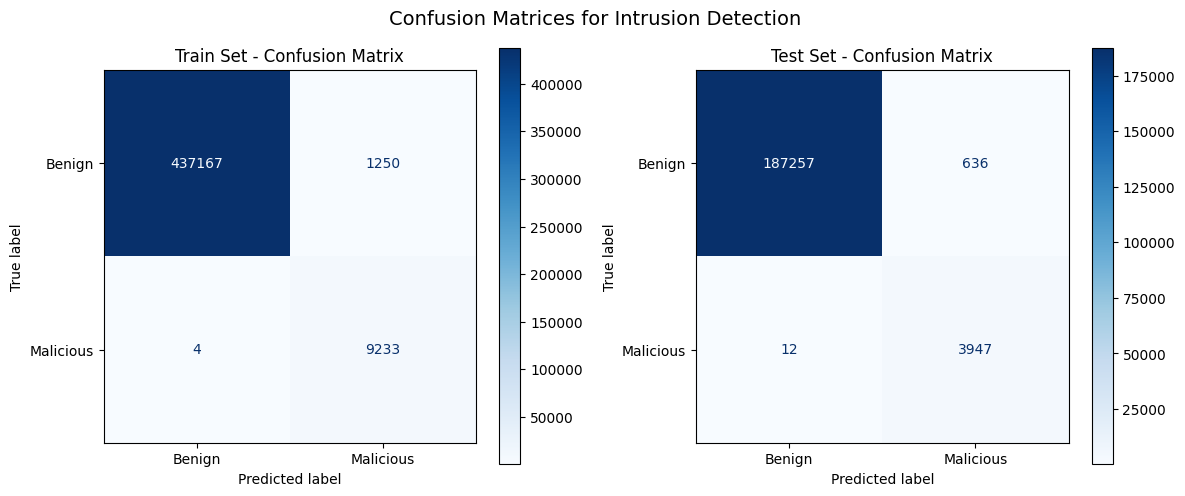

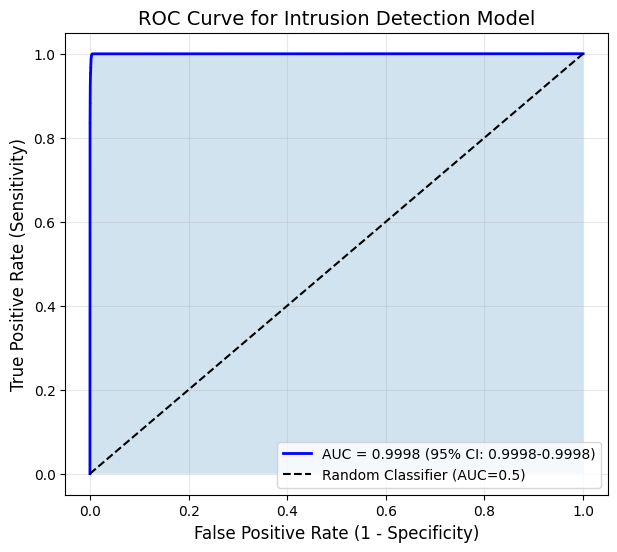

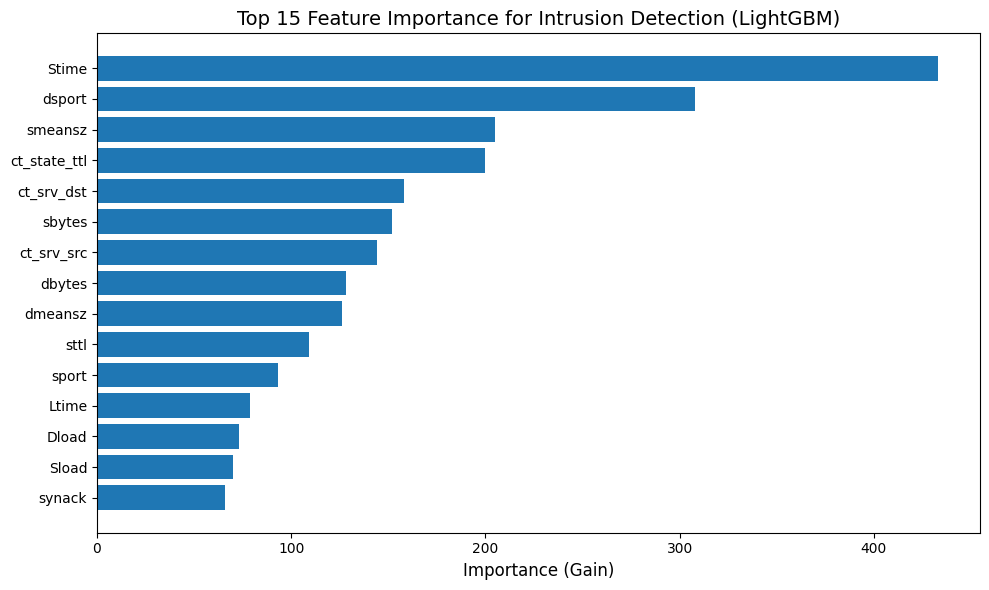


Top 10 features:
          Feature  Importance
23         Stime         433
1         dsport         308
17       smeansz         205
31  ct_state_ttl         200
36    ct_srv_dst         158
3         sbytes         152
35    ct_srv_src         144
4         dbytes         128
18       dmeansz         126
5           sttl         109

SHAP analysis (sampling 100 test samples)...

FEATURE IMPORTANCE BASED ON SHAP

Feature                        Strength     Impact %  
------------------------------------------------------------
ct_state_ttl                   0.1664       49.32     
sttl                           0.1264       37.46     
dsport                         0.0078       2.31      
dbytes                         0.0055       1.62      
Dload                          0.0050       1.47      
smeansz                        0.0050       1.47      
dmeansz                        0.0049       1.46      
Ltime                          0.0048       1.42      
ct_srv_dst               

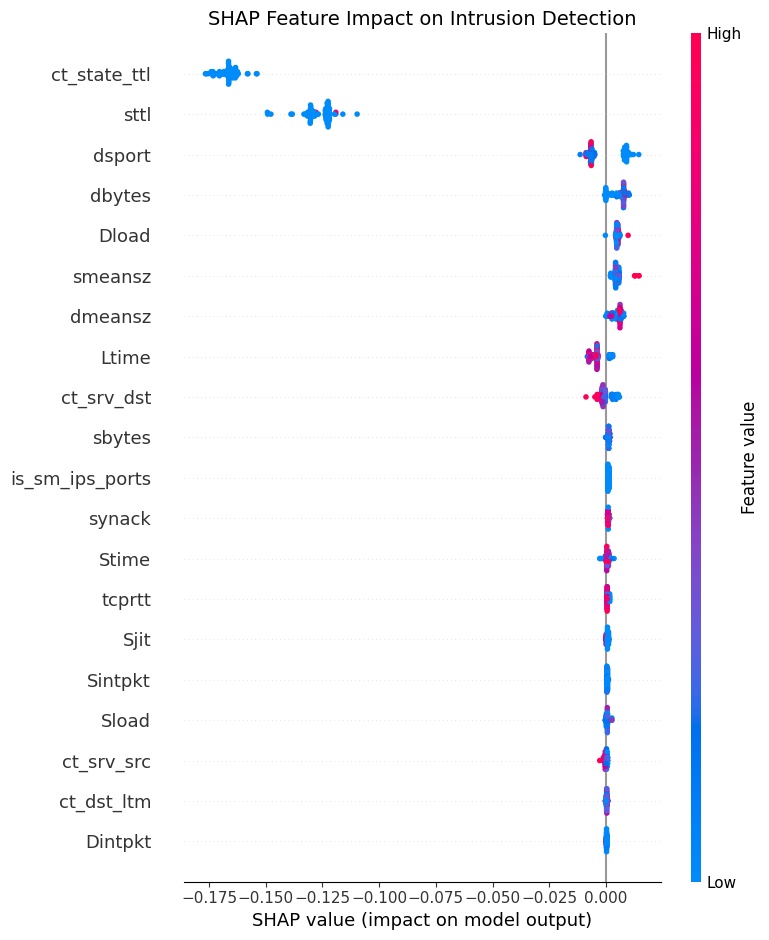

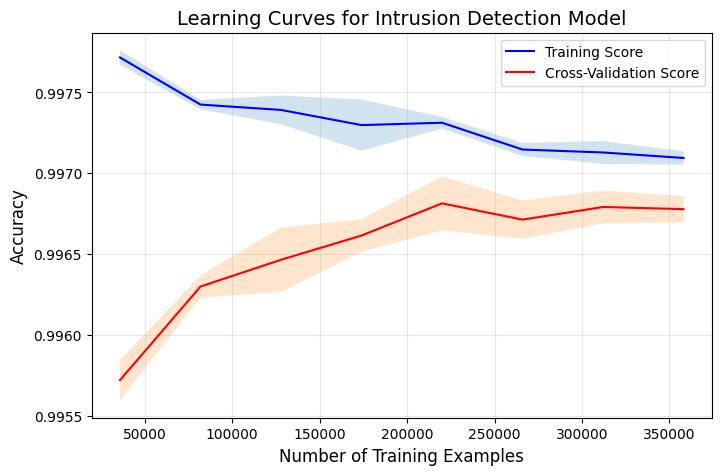


Comparing with individual models on test set...
          Accuracy  Balanced Acc  Precision  Recall      F1     MCC   Kappa  \
xgb         0.9978        0.9760     0.9978  0.9978  0.9978  0.9463  0.9463   
Ensemble    0.9966        0.9968     0.9971  0.9966  0.9967  0.9250  0.9224   
lgb         0.9958        0.9972     0.9965  0.9958  0.9959  0.9086  0.9045   

          Specificity  Sensitivity     AUC  
xgb            0.9988       0.9533  0.9998  
Ensemble       0.9966       0.9970  0.9998  
lgb            0.9957       0.9987  0.9998  


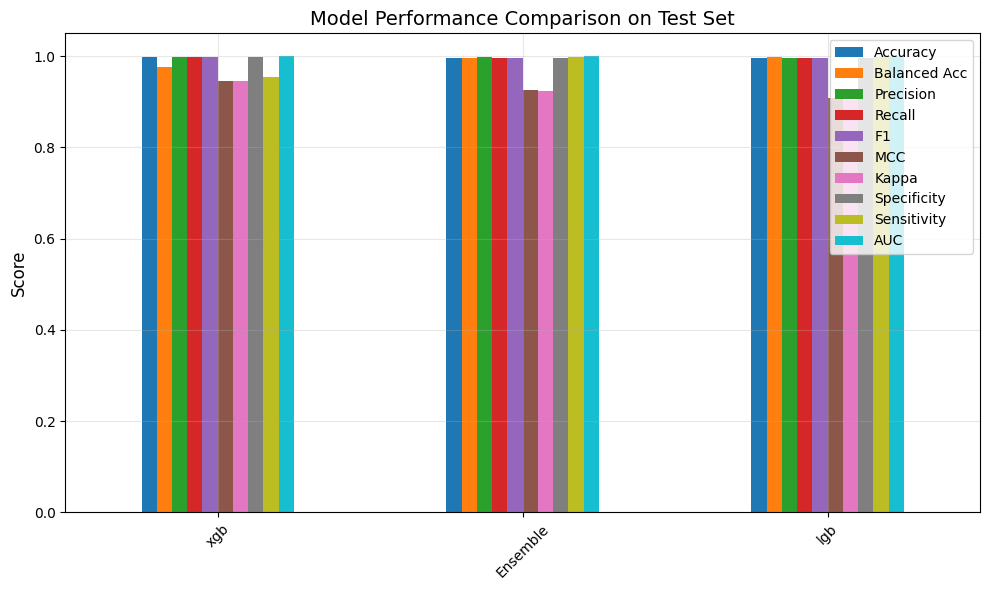


McNemar's test (Ensemble vs Logistic Regression): p-value = 0.000000
Result: Statistically significant difference (p < 0.05)

Model saved to fast_ids_model.pkl

FINAL CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    187893
   Malicious       0.86      1.00      0.92      3959

    accuracy                           1.00    191852
   macro avg       0.93      1.00      0.96    191852
weighted avg       1.00      1.00      1.00    191852


INTRUSION DETECTION SYSTEM - COMPLETED SUCCESSFULLY
Results saved in: ids_results/

Sample predictions on test instances:
  Correct | True: Benign    | Predicted: Benign   
  Correct | True: Benign    | Predicted: Benign   
  Correct | True: Benign    | Predicted: Benign   
  Correct | True: Malicious | Predicted: Malicious
  Correct | True: Benign    | Predicted: Benign   

Total execution time: 22.35 minutes


In [15]:

start_time = time.time()

# ==============================
# 1. CONFIGURATION
# ==============================
class Config:
    RANDOM_STATE = 42
    TEST_SIZE = 0.3
    N_FOLDS = 10
    N_JOBS = -1
    MODEL_SAVE_PATH = "fast_ids_model.pkl"
    RESULTS_PATH = "ids_results/"

    LGB_PARAMS = {
        'n_estimators': 100,
        'learning_rate': 0.05,
        'num_leaves': 31,
        'random_state': RANDOM_STATE,
        'n_jobs': N_JOBS,
        'class_weight': 'balanced',
        'verbose': -1
    }

    XGB_PARAMS = {
        'n_estimators': 200,
        'learning_rate': 0.05,
        'max_depth': 6,
        'random_state': RANDOM_STATE,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'n_jobs': N_JOBS
    }

config = Config()
import os
os.makedirs(config.RESULTS_PATH, exist_ok=True)

# ==============================
# 2. DATA LOADING & BALANCING
# ==============================
print("="*60)
print("INTRUSION DETECTION SYSTEM")
print("Network Malicious Detection (Benign vs Malicious)")
print("="*60)

# df = pd.read_csv('UNSW_NB15_1_cleaned.csv')
df = clean_df.copy()
print(f"All NUSW-NB15_1 Dataset shape: {df.shape}")

df.drop_duplicates(inplace=True)
print(f"Dataset after drop duplicates: {df.shape}")

print("="*60)
print(f"Label (Benign and Malicious) counts:\n{df['Label'].value_counts()}")


# ==============================
# 3. FEATURE SELECTION (Drop irrelevant columns)
# ==============================
X = df.drop(['Label'], axis=1)
y = df['Label']
print(f"\nFeatures after cleaning: {X.shape[1]}")

# ==============================
# 4. SINGLE TRAIN/TEST SPLIT (70/30)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE, stratify=y
)


print(f"\nData split: Train={len(X_train)} ({100*(1-config.TEST_SIZE):.0f}%), Test={len(X_test)} ({100*config.TEST_SIZE:.0f}%)")

# ==============================
# 5. DEFINE MODELS AND ENSEMBLE
# ==============================
models = {
    'xgb': XGBClassifier(**config.XGB_PARAMS),
    'lgb': lgb.LGBMClassifier(**config.LGB_PARAMS),
}

voted_clf = VotingClassifier(
    estimators=[(name, model) for name, model in models.items()],
    voting='soft',
    weights=[2, 2]
)

# ==============================
# 6. BUILD PIPELINE (Only scaling)
# ==============================
full_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('ensemble', voted_clf)
])

# ==============================
# 7. TRAINING
# ==============================
print("\nTraining model...")
train_start = time.time()
full_pipeline.fit(X_train, y_train)
train_time = time.time() - train_start
print(f"Training time: {train_time:.2f} seconds")

# ==============================
# 8. CROSS-VALIDATION (ON TRAINING SET ONLY)
# ==============================
print("\nCross-Validation (on training set)...")
skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)
cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=config.N_JOBS)
print(f"{config.N_FOLDS}-Fold CV Accuracy on Train: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ==============================
# 9. EVALUATION FUNCTION (only on train and test)
# ==============================
def evaluate(model, X_train, X_test, y_train, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    def metrics(y_true, y_pred, y_proba=None):
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        return {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted'),
            'Recall': recall_score(y_true, y_pred, average='weighted'),
            'F1': f1_score(y_true, y_pred, average='weighted'),
            'MCC': matthews_corrcoef(y_true, y_pred),
            'Kappa': cohen_kappa_score(y_true, y_pred),
            'Specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
            'Sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
            'AUC': roc_auc_score(y_true, y_proba) if y_proba is not None else 0
        }

    train_metrics = metrics(y_train, train_pred)
    test_metrics = metrics(y_test, test_pred, test_proba)
    return train_metrics, test_metrics, test_pred, test_proba

train_m, test_m, test_pred, test_proba = evaluate(full_pipeline, X_train, X_test, y_train, y_test)

print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
for metric in test_m:
    print(f"{metric:15} | Train: {train_m[metric]*100:.2f}% | Test: {test_m[metric]*100:.2f}%")

# ==============================
# 10. CONFUSION MATRICES (Train and Test)
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, name, y_d, preds in zip(axes, ['Train','Test'], [y_train, y_test],
                                 [full_pipeline.predict(X_train), test_pred]):
    cm = confusion_matrix(y_d, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malicious'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{name} Set - Confusion Matrix')
plt.suptitle('Confusion Matrices for Intrusion Detection', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}confusion_matrices.png', dpi=150)
plt.show()

# ==============================
# 11. ROC CURVE WITH CONFIDENCE INTERVAL (on Test set)
# ==============================
fpr, tpr, _ = roc_curve(y_test, test_proba)
auc_val = test_m['AUC']

# Bootstrap CI
aucs_boot = []
rng = np.random.RandomState(config.RANDOM_STATE)
for _ in range(500):
    idx = rng.choice(len(y_test), len(y_test), replace=True)
    if len(np.unique(y_test.iloc[idx])) < 2:
        continue
    aucs_boot.append(roc_auc_score(y_test.iloc[idx], test_proba[idx]))
ci_low, ci_high = np.percentile(aucs_boot, [2.5, 97.5])

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.4f} (95% CI: {ci_low:.4f}-{ci_high:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random Classifier (AUC=0.5)')
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve for Intrusion Detection Model', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig(f'{config.RESULTS_PATH}roc_curve.png', dpi=150)
plt.show()

# ==============================
# 12. FEATURE IMPORTANCE (LightGBM)
# ==============================
lgb_model = full_pipeline.named_steps['ensemble'].named_estimators_['lgb']
X_train_scaled = full_pipeline.named_steps['scaler'].transform(X_train)
importances = lgb_model.feature_importances_
feature_names = X_train.columns

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(imp_df['Feature'][:15][::-1], imp_df['Importance'][:15][::-1])
plt.xlabel('Importance (Gain)', fontsize=12)
plt.title('Top 15 Feature Importance for Intrusion Detection (LightGBM)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}feature_importance.png', dpi=150)
plt.show()
print("\nTop 10 features:\n", imp_df.head(10))


# ==============================
# 13. SHAP ANALYSIS (on test set sample)
# ==============================
try:
    print("\nSHAP analysis (sampling 100 test samples)...")
    X_test_sampled = X_test[:100]
    X_test_scaled = full_pipeline.named_steps['scaler'].transform(X_test_sampled)
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    importance_percentage = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_results = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Strength': mean_abs_shap, 
        'Impact_%': importance_percentage  
    }).sort_values('SHAP_Strength', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE BASED ON SHAP")
    print("="*60)
    print(f"\n{'Feature':<30} {'Strength':<12} {'Impact %':<10}")
    print("-"*60)
    
    for i, row in shap_results.head(15).iterrows():
        print(f"{row['Feature']:<30} {row['SHAP_Strength']:<12.4f} {row['Impact_%']:<10.2f}")
    
    print("="*60)
    print(f"\nTop feature: {shap_results.iloc[0]['Feature']} (Impact: {shap_results.iloc[0]['Impact_%']:.2f}%)")
    print(f"Second feature: {shap_results.iloc[1]['Feature']} (Impact: {shap_results.iloc[1]['Impact_%']:.2f}%)")
    print(f"Third feature: {shap_results.iloc[2]['Feature']} (Impact: {shap_results.iloc[2]['Impact_%']:.2f}%)")
    
    shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Impact on Intrusion Detection', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}shap_summary.png', dpi=150)
    plt.show()
    
except Exception as e:
    print(f"SHAP skipped: {e}")

# ==============================
# 14. LEARNING CURVES (using train/test split, not validation)
# ==============================
train_sizes, train_scores, val_scores = learning_curve(
    full_pipeline, X_train, y_train, cv=5, train_sizes=np.linspace(0.1,1,8),
    scoring='accuracy', n_jobs=config.N_JOBS)
train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
val_mean, val_std = np.mean(val_scores, axis=1), np.std(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'b-', label='Training Score')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.plot(train_sizes, val_mean, 'r-', label='Cross-Validation Score')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Learning Curves for Intrusion Detection Model', fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.savefig(f'{config.RESULTS_PATH}learning_curves.png', dpi=150)
plt.show()

# ==============================
# 15. COMPARISON WITH INDIVIDUAL MODELS (on test set)
# ==============================
print("\nComparing with individual models on test set...")
comparison = {}
for name, model in models.items():
    pipe = Pipeline([('scaler', RobustScaler()), ('clf', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    comp = {
        'Accuracy': accuracy_score(y_test, pred),
        'Balanced Acc': balanced_accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall': recall_score(y_test, pred, average='weighted'),
        'F1': f1_score(y_test, pred, average='weighted'),
        'MCC': matthews_corrcoef(y_test, pred),
        'Kappa': cohen_kappa_score(y_test, pred),
        'Specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
        'Sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
        'AUC': roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    }
    comparison[name] = comp
comparison['Ensemble'] = {
    'Accuracy': test_m['Accuracy'], 
    'Balanced Acc': test_m['Balanced Acc'], 
    'Precision': test_m['Precision'],
    'Accuracy': test_m['Accuracy'], 
    'Recall': test_m['Recall'], 
    'F1': test_m['F1'],
    'MCC': test_m['MCC'], 
    'Kappa': test_m['Kappa'], 
    'Specificity': test_m['Specificity'],
    'Sensitivity': test_m['Sensitivity'],
    'AUC': test_m['AUC']
    }
comp_df = pd.DataFrame(comparison).T.sort_values('Accuracy', ascending=False)
print(comp_df.round(4))

comp_df.plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison on Test Set', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}model_comparison.png', dpi=150)
plt.show()

# ==============================
# 16. MCNEMAR'S TEST (Ensemble vs Logistic Regression)
# ==============================
base_pipe = Pipeline([('scaler', RobustScaler()), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
base_pipe.fit(X_train, y_train)
base_pred = base_pipe.predict(X_test)
contingency = pd.crosstab(test_pred, base_pred)
mcnemar_res = mcnemar(contingency, exact=True)
print(f"\nMcNemar's test (Ensemble vs Logistic Regression): p-value = {mcnemar_res.pvalue:.6f}")
if mcnemar_res.pvalue < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: No statistically significant difference")

# ==============================
# 17. SAVE MODEL AND RESULTS
# ==============================
joblib.dump(full_pipeline, config.MODEL_SAVE_PATH)
print(f"\nModel saved to {config.MODEL_SAVE_PATH}")

summary = pd.DataFrame([{
    'Train_Time_sec': train_time,
    'CV_Mean_Accuracy': cv_scores.mean(),
    'CV_Std': cv_scores.std(),
    'Test_Accuracy': test_m['Accuracy'],
    'Test_F1': test_m['F1'],
    'Test_AUC': test_m['AUC'],
    'Test_MCC': test_m['MCC'],
    'Test_Sensitivity': test_m['Sensitivity'],
    'Test_Specificity': test_m['Specificity']
}])
summary.to_csv(f'{config.RESULTS_PATH}summary.csv', index=False)

# ==============================
# 18. FINAL CLASSIFICATION REPORT
# ==============================
print("\n" + "="*60)
print("FINAL CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test, test_pred, target_names=['Benign', 'Malicious']))

print("\n" + "="*60)
print("INTRUSION DETECTION SYSTEM - COMPLETED SUCCESSFULLY")
print(f"Results saved in: {config.RESULTS_PATH}")
print("="*60)

# ==============================
# 19. SAMPLE PREDICTIONS
# ==============================
sample_idx = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)
print("\nSample predictions on test instances:")
for idx in sample_idx:
    true_label = "Malicious" if y_test.iloc[idx] == 1 else "Benign"
    pred_label = "Malicious" if full_pipeline.predict(X_test.iloc[[idx]])[0] == 1 else "Benign"
    status = "Correct" if y_test.iloc[idx] == full_pipeline.predict(X_test.iloc[[idx]])[0] else "Wrong"
    print(f"  {status:7} | True: {true_label:9} | Predicted: {pred_label:9}")

total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time/60:.2f} minutes")
print("="*60)


SHAP analysis (sampling 500 test samples)...

FEATURE IMPORTANCE BASED ON SHAP

Feature                        Strength     Impact %  
------------------------------------------------------------
ct_state_ttl                   0.2442       47.60     
sttl                           0.1980       38.59     
dsport                         0.0147       2.86      
smeansz                        0.0077       1.50      
dbytes                         0.0068       1.33      
Ltime                          0.0055       1.06      
dmeansz                        0.0054       1.06      
ct_srv_dst                     0.0053       1.04      
Dload                          0.0053       1.03      
Stime                          0.0029       0.56      
Spkts                          0.0024       0.47      
is_sm_ips_ports                0.0020       0.39      
synack                         0.0019       0.37      
sbytes                         0.0017       0.33      
tcprtt                         0.

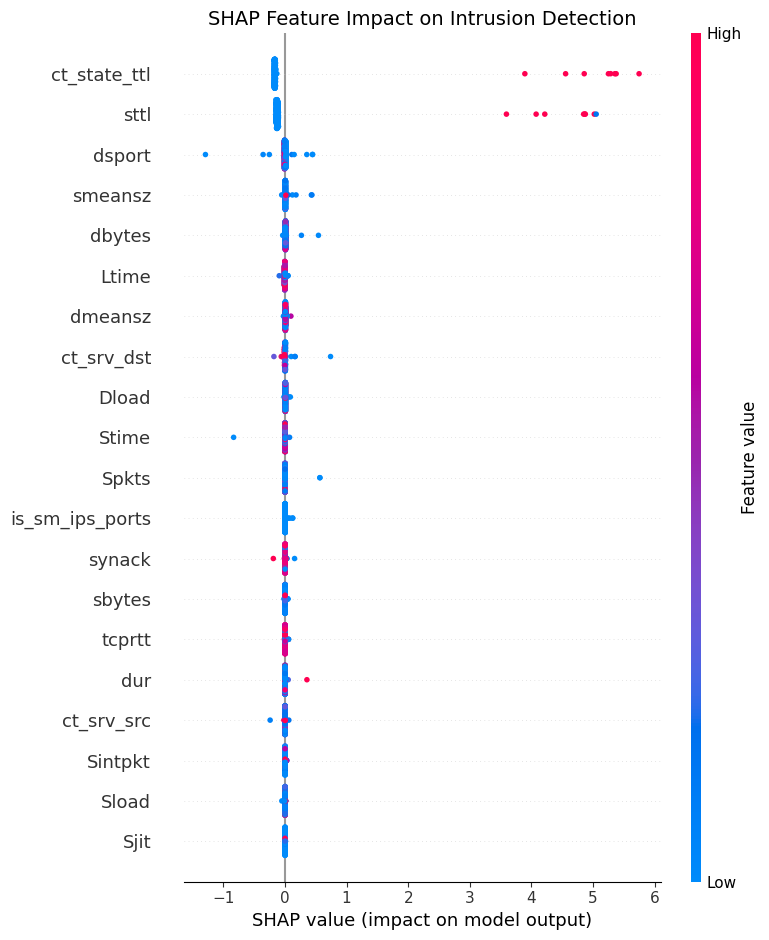

In [16]:

# ==============================
# 13. SHAP ANALYSIS (on test set sample)
# ==============================
try:
    print("\nSHAP analysis (sampling 500 test samples)...")
    X_test_sampled = X_test[:500]
    X_test_scaled = full_pipeline.named_steps['scaler'].transform(X_test_sampled)
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    importance_percentage = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_results = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Strength': mean_abs_shap, 
        'Impact_%': importance_percentage  
    }).sort_values('SHAP_Strength', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE BASED ON SHAP")
    print("="*60)
    print(f"\n{'Feature':<30} {'Strength':<12} {'Impact %':<10}")
    print("-"*60)
    
    for i, row in shap_results.head(15).iterrows():
        print(f"{row['Feature']:<30} {row['SHAP_Strength']:<12.4f} {row['Impact_%']:<10.2f}")
    
    print("="*60)
    print(f"\nTop feature: {shap_results.iloc[0]['Feature']} (Impact: {shap_results.iloc[0]['Impact_%']:.2f}%)")
    print(f"Second feature: {shap_results.iloc[1]['Feature']} (Impact: {shap_results.iloc[1]['Impact_%']:.2f}%)")
    print(f"Third feature: {shap_results.iloc[2]['Feature']} (Impact: {shap_results.iloc[2]['Impact_%']:.2f}%)")
    
    shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Impact on Intrusion Detection', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}shap_summary.png', dpi=150)
    plt.show()
    
except Exception as e:
    print(f"SHAP skipped: {e}")



SHAP analysis (sampling 1000 test samples)...

FEATURE IMPORTANCE BASED ON SHAP

Feature                        Strength     Impact %  
------------------------------------------------------------
ct_state_ttl                   0.2542       47.05     
sttl                           0.2082       38.52     
dsport                         0.0190       3.51      
smeansz                        0.0080       1.48      
dbytes                         0.0062       1.15      
Ltime                          0.0059       1.10      
dmeansz                        0.0057       1.05      
Dload                          0.0054       1.01      
ct_srv_dst                     0.0049       0.90      
Stime                          0.0036       0.66      
is_sm_ips_ports                0.0029       0.53      
sbytes                         0.0023       0.43      
synack                         0.0020       0.37      
Spkts                          0.0016       0.29      
tcprtt                         0

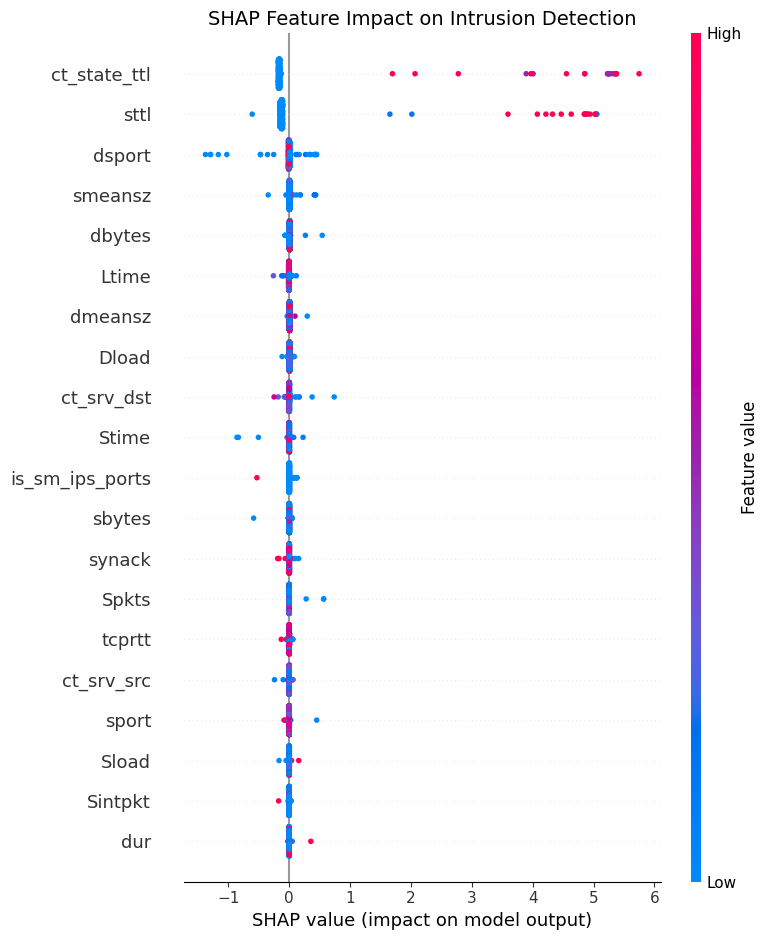

In [17]:

# ==============================
# 13. SHAP ANALYSIS (on test set sample)
# ==============================
try:
    print("\nSHAP analysis (sampling 1000 test samples)...")
    X_test_sampled = X_test[:1000]
    X_test_scaled = full_pipeline.named_steps['scaler'].transform(X_test_sampled)
    explainer = shap.TreeExplainer(lgb_model)
    shap_vals = explainer.shap_values(X_test_scaled)
    
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]
    
    mean_abs_shap = np.mean(np.abs(shap_vals), axis=0)
    
    importance_percentage = (mean_abs_shap / mean_abs_shap.sum()) * 100
    
    shap_results = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Strength': mean_abs_shap, 
        'Impact_%': importance_percentage  
    }).sort_values('SHAP_Strength', ascending=False)
    
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE BASED ON SHAP")
    print("="*60)
    print(f"\n{'Feature':<30} {'Strength':<12} {'Impact %':<10}")
    print("-"*60)
    
    for i, row in shap_results.head(15).iterrows():
        print(f"{row['Feature']:<30} {row['SHAP_Strength']:<12.4f} {row['Impact_%']:<10.2f}")
    
    print("="*60)
    print(f"\nTop feature: {shap_results.iloc[0]['Feature']} (Impact: {shap_results.iloc[0]['Impact_%']:.2f}%)")
    print(f"Second feature: {shap_results.iloc[1]['Feature']} (Impact: {shap_results.iloc[1]['Impact_%']:.2f}%)")
    print(f"Third feature: {shap_results.iloc[2]['Feature']} (Impact: {shap_results.iloc[2]['Impact_%']:.2f}%)")
    
    shap.summary_plot(shap_vals, X_test_scaled, feature_names=feature_names, show=False)
    plt.title('SHAP Feature Impact on Intrusion Detection', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}shap_summary.png', dpi=150)
    plt.show()
    
except Exception as e:
    print(f"SHAP skipped: {e}")
